In [114]:
# 7-8-2026

In [134]:
import pandas as pd
import numpy as np
from scipy.stats import kendalltau

In [135]:
true_matrix = pd.read_csv("../transfer-matrix/rf_transfer_matrix.csv")
true_matrix.set_index("Unnamed: 0", inplace=True)
true_matrix.index.name = None
true_matrix.index = true_matrix.index.astype(int)
true_matrix.columns = true_matrix.columns.astype(int)
true_matrix.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.392727,0.291660,0.127238,0.058840,0.214817,0.084705,0.149056,0.182358,0.173877,0.026375,...,0.228505,0.243433,0.149609,0.275203,0.112525,-0.011557,0.116862,0.158796,0.025454,0.029928
1,0.142172,0.395760,0.030643,0.010376,0.180707,0.064432,0.056092,0.128808,0.097788,0.039590,...,0.167477,0.032806,0.029704,0.193033,0.055264,0.066550,0.108203,0.199762,0.023240,-0.037710
2,0.196600,0.214445,0.368173,0.023968,0.207323,0.140139,0.172990,0.231019,0.156741,0.057226,...,0.197402,0.223793,0.121457,0.248807,0.134485,0.053503,-0.005610,0.253965,0.031899,0.059566
4,0.235489,0.227173,0.127394,0.410382,0.215954,0.186207,0.125068,0.196603,0.165264,0.034514,...,0.178055,0.245668,0.147579,0.284360,0.217076,-0.003941,0.037643,0.306750,0.137154,0.020968
5,0.190803,0.206530,0.097887,0.087230,0.464604,0.144950,0.159361,0.204884,0.264641,0.104493,...,0.197195,0.232923,0.117228,0.292623,0.170687,-0.020694,0.115293,0.297271,0.067951,0.051770


In [136]:
xgb_matrix = pd.read_csv("xgboost_transfer_matrix.csv")
xgb_matrix.set_index("Unnamed: 0", inplace=True)
xgb_matrix.index.name = None
xgb_matrix.index = xgb_matrix.index.astype(int)
xgb_matrix.columns = xgb_matrix.columns.astype(int)
xgb_matrix.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.422916,0.267405,0.118854,0.072110,0.209210,0.089300,0.140259,0.197033,0.172163,0.043448,...,0.204125,0.197841,0.141550,0.271657,0.159073,-0.003677,0.119032,0.145833,0.136358,0.088174
1,0.132224,0.372937,0.018774,0.026538,0.159494,0.056353,0.050307,0.122099,0.083579,0.035342,...,0.148052,0.047564,0.033311,0.184790,0.051414,0.058260,0.033156,0.085162,0.035086,0.071975
2,0.197729,0.214376,0.411347,0.042563,0.206085,0.117786,0.164529,0.223776,0.162216,0.056164,...,0.186268,0.194283,0.120743,0.258035,0.149518,0.043629,0.138142,0.109870,0.094973,0.097347
4,0.207481,0.216066,0.128431,0.401729,0.209708,0.171541,0.136227,0.191305,0.164637,0.051143,...,0.180342,0.241195,0.166199,0.280389,0.200734,0.002234,0.119535,0.222951,0.178340,0.100695
5,0.217136,0.229034,0.101726,0.086549,0.453289,0.124287,0.147896,0.217123,0.229876,0.094095,...,0.198625,0.207909,0.126130,0.293456,0.179496,0.001818,0.135826,0.129731,0.143467,0.098206


In [137]:
wasserstein_T = pd.read_csv("wasserstein_transfer_matrix.csv")
wasserstein_T.set_index("Unnamed: 0", inplace=True)
wasserstein_T.index.name = None
wasserstein_T.index = wasserstein_T.index.astype(int)
wasserstein_T.columns = wasserstein_T.columns.astype(int)
wasserstein_T.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,-0.000000,-0.370185,-0.821919,-0.631151,-0.271254,-0.618940,-0.601552,-0.373546,-0.467406,-0.642084,...,-0.542250,-0.748647,-0.583704,-0.311792,-0.580063,-1.038575,-0.659135,-0.584165,-0.850571,-0.426040
1,-0.370185,-0.000000,-1.059865,-0.645369,-0.345514,-0.668876,-0.784808,-0.343439,-0.598186,-0.817843,...,-0.781894,-0.947472,-0.841470,-0.268515,-0.745543,-1.256589,-0.893460,-0.560869,-1.015066,-0.557277
2,-0.821919,-1.059865,-0.000000,-1.264502,-0.902122,-1.175253,-0.597994,-1.038391,-0.615981,-0.648922,...,-0.377196,-0.731583,-0.733522,-0.924926,-0.604379,-0.606957,-0.487535,-1.092401,-1.114370,-0.855791
4,-0.631151,-0.645369,-1.264502,-0.000000,-0.666719,-0.202338,-0.915700,-0.758750,-0.769389,-1.022609,...,-1.019270,-0.670806,-0.645739,-0.676449,-0.878022,-1.320014,-1.104098,-0.402692,-0.475635,-0.629141
5,-0.271254,-0.345514,-0.902122,-0.666719,-0.000000,-0.625025,-0.503692,-0.402572,-0.462900,-0.533302,...,-0.604440,-0.826448,-0.659611,-0.315339,-0.505676,-1.002581,-0.662484,-0.643484,-0.846411,-0.512717


In [138]:
mmd_T = pd.read_csv("mmd_transfer_matrix.csv")
mmd_T.set_index("Unnamed: 0", inplace=True)
mmd_T.index.name = None
mmd_T.index = mmd_T.index.astype(int)
mmd_T.columns = mmd_T.columns.astype(int)
mmd_T.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,-0.000000,-0.091753,-0.295190,-0.220502,-0.046464,-0.210145,-0.177884,-0.069680,-0.116900,-0.199710,...,-0.141869,-0.225514,-0.162635,-0.061955,-0.161644,-0.419346,-0.217384,-0.165180,-0.317172,-0.095015
1,-0.091753,-0.000000,-0.547598,-0.271180,-0.082083,-0.270786,-0.342029,-0.089200,-0.221858,-0.388278,...,-0.355044,-0.391497,-0.325813,-0.041312,-0.300087,-0.655168,-0.438146,-0.163378,-0.494685,-0.192390
2,-0.295190,-0.547598,-0.000000,-0.565534,-0.414482,-0.517862,-0.208324,-0.436485,-0.226869,-0.319881,...,-0.091695,-0.219412,-0.229660,-0.397175,-0.193048,-0.195189,-0.144865,-0.461812,-0.518829,-0.311635
4,-0.220502,-0.271180,-0.565534,-0.000000,-0.252171,-0.015105,-0.335054,-0.295700,-0.282398,-0.436782,...,-0.443404,-0.186991,-0.165344,-0.251971,-0.320255,-0.562626,-0.540233,-0.070253,-0.117704,-0.198213
5,-0.046464,-0.082083,-0.414482,-0.252171,-0.000000,-0.239118,-0.183065,-0.078711,-0.125252,-0.166563,...,-0.222090,-0.303790,-0.212553,-0.056273,-0.168546,-0.494505,-0.257269,-0.197364,-0.366313,-0.159041


In [139]:
no_encoder_matrix = pd.read_csv("no_encoder_predicted_transfer_matrix.csv")
no_encoder_matrix.set_index("Unnamed: 0", inplace=True)
no_encoder_matrix.index.name = None
no_encoder_matrix.index = no_encoder_matrix.index.astype(int)
no_encoder_matrix.columns = no_encoder_matrix.columns.astype(int)
no_encoder_matrix.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.247472,0.229359,0.061232,0.063558,0.218862,0.065449,0.117259,0.184827,0.164134,0.051984,...,0.132958,0.168679,0.118727,0.273036,0.166067,0.004561,0.100947,0.160124,0.050890,0.078829
1,0.074180,0.287130,0.024224,0.032911,0.089247,0.034773,0.025694,0.117067,0.045449,0.043299,...,0.077485,0.041540,0.039043,0.140902,0.017065,0.031797,0.051239,0.103002,0.023303,0.008500
2,0.166948,0.141675,0.295710,0.073611,0.163935,0.068916,0.119261,0.170031,0.155390,0.086576,...,0.142728,0.128812,0.081920,0.192740,0.135407,0.033392,0.168192,0.109553,0.068842,0.063720
4,0.164804,0.182907,0.133407,0.270750,0.148438,0.171554,0.103389,0.150635,0.119382,0.047948,...,0.128869,0.167683,0.119842,0.237631,0.112197,0.027904,0.119330,0.188634,0.204398,0.086597
5,0.153668,0.220502,0.059987,0.075525,0.242856,0.092696,0.135654,0.126450,0.200498,0.072853,...,0.200072,0.154216,0.130375,0.298928,0.146545,0.005896,0.138272,0.173696,0.068507,0.062065


In [140]:
rawdist_matrix = pd.read_csv("rawdist_matrix.csv")
rawdist_matrix.set_index("Unnamed: 0", inplace=True)
rawdist_matrix.index.name = None
rawdist_matrix.index = rawdist_matrix.index.astype(int)
rawdist_matrix.columns = rawdist_matrix.columns.astype(int)
rawdist_matrix.head(10)

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,-0.000000,-6.672423,-11.045133,-7.986460,-3.308284,-7.958821,-6.068376,-4.666705,-5.184888,-4.589527,...,-7.662378,-6.407206,-8.197987,-5.296501,-4.204545,-11.505974,-7.273316,-13.276326,-6.751253,-3.125536
1,-6.672423,-0.000000,-13.599319,-9.841238,-5.547623,-9.436429,-9.730264,-5.698760,-8.974480,-8.392720,...,-11.038897,-10.159206,-10.744922,-5.711799,-7.998925,-13.061897,-11.181847,-15.567050,-8.537365,-6.931799
2,-11.045133,-13.599319,-0.000000,-13.082436,-11.499412,-12.708249,-9.285989,-13.684210,-9.565427,-8.687225,...,-7.894825,-9.563264,-10.696453,-11.590126,-9.063832,-9.620238,-7.577379,-16.658596,-9.353973,-11.288658
4,-7.986460,-9.841238,-13.082436,-0.000000,-8.019986,-3.351193,-7.878595,-9.379059,-9.467587,-9.484902,...,-10.290864,-7.254905,-6.459036,-9.505884,-7.903673,-13.860378,-11.642435,-9.120748,-5.452087,-7.889157
5,-3.308284,-5.547623,-11.499412,-8.019986,-0.000000,-7.551036,-6.591061,-4.260023,-4.860621,-5.079144,...,-8.673302,-7.712744,-8.004912,-4.035172,-5.374218,-12.376469,-7.461498,-12.675088,-6.924344,-4.980700
6,-7.958821,-9.436429,-12.708249,-3.351193,-7.551036,-0.000000,-7.307292,-8.895403,-9.258151,-9.329919,...,-9.975772,-7.488843,-4.461359,-9.152761,-7.552179,-13.639737,-11.240952,-8.347249,-5.771723,-7.863910
7,-6.068376,-9.730264,-9.285989,-7.878595,-6.591061,-7.307292,-0.000000,-8.832793,-7.072502,-5.136909,...,-4.850997,-4.276811,-5.501850,-8.444666,-2.986468,-8.724586,-7.209533,-12.837734,-5.064828,-5.701705
8,-4.666705,-5.698760,-13.684210,-9.379059,-4.260023,-8.895403,-8.832793,-0.000000,-7.504786,-7.592999,...,-10.594288,-8.880334,-9.930977,-5.531485,-7.389167,-14.100157,-10.431665,-13.559093,-9.241698,-5.032279
11,-5.184888,-8.974480,-9.565427,-9.467587,-4.860621,-9.258151,-7.072502,-7.504786,-0.000000,-5.607953,...,-8.563762,-8.084519,-8.778158,-4.434500,-6.187654,-12.536701,-4.309561,-13.146039,-7.716434,-6.559332
12,-4.589527,-8.392720,-8.687225,-9.484902,-5.079144,-9.329919,-5.136909,-7.592999,-5.607953,-0.000000,...,-6.457259,-6.402053,-8.537121,-6.857717,-4.288140,-9.152598,-5.360677,-14.267618,-6.997054,-5.922538


In [141]:
embedding_matrix2 = pd.read_csv("../probing/embedding_matrix_v2.csv")
embedding_matrix2.set_index("domain_id", inplace=True)
embedding_matrix2.index.name = None
embedding_matrix2.index = embedding_matrix2.index.astype(int)
embedding_matrix2.columns = embedding_matrix2.columns.astype(int)
embedding_matrix2.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,-0.000000,-1.283791,-0.526716,-0.768367,-0.284379,-0.730119,-0.813101,-0.586308,-0.539763,-1.386452,...,-0.883986,-0.553056,-0.692510,-0.909542,-0.431134,-2.958495,-1.050950,-0.930292,-0.609290,-0.562334
1,-1.283791,-0.000000,-1.740825,-1.927705,-1.286479,-1.955912,-2.036067,-0.763700,-1.584322,-1.953257,...,-1.990409,-1.747790,-1.944240,-1.310502,-1.659987,-3.069270,-1.923802,-2.143102,-1.788747,-1.411729
2,-0.526716,-1.740825,-0.000000,-0.545822,-0.546466,-0.458187,-0.587568,-1.026400,-0.548009,-1.517400,...,-0.855306,-0.517830,-0.450876,-1.178803,-0.347590,-3.192266,-0.920493,-0.775952,-0.369576,-0.675117
4,-0.768367,-1.927705,-0.545822,-0.000000,-0.922929,-0.251164,-0.456162,-1.211518,-0.973311,-1.162037,...,-0.822570,-0.440507,-0.382822,-1.592120,-0.486005,-2.840285,-1.393789,-0.819681,-0.221860,-0.615110
5,-0.284379,-1.286479,-0.546466,-0.922929,-0.000000,-0.881718,-0.957936,-0.653677,-0.346508,-1.597839,...,-0.951680,-0.737359,-0.835023,-0.709408,-0.601795,-3.152650,-0.819343,-0.998892,-0.748704,-0.763223


In [142]:
embedding_matrix3 = pd.read_csv("../probing/embedding_matrix_v3.csv")
embedding_matrix3.set_index("domain_id", inplace=True)
embedding_matrix3.index.name = None
embedding_matrix3.index = embedding_matrix3.index.astype(int)
embedding_matrix3.columns = embedding_matrix3.columns.astype(int)
embedding_matrix3.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,-0.000000,-1.097939,-1.224242,-1.312257,-0.282035,-1.017579,-0.467399,-0.500967,-0.743199,-0.986187,...,-0.499771,-0.663056,-0.637163,-0.755550,-0.284533,-1.695991,-1.189250,-1.618741,-0.711346,-0.870055
1,-1.097939,-0.000000,-1.918557,-1.949771,-1.192345,-1.673653,-1.355785,-0.734422,-1.614340,-1.711187,...,-1.265848,-1.444148,-1.484107,-1.116822,-1.237794,-1.797731,-1.856895,-2.274187,-1.513679,-1.218239
2,-1.224242,-1.918557,-0.000000,-1.681366,-1.139217,-1.505432,-1.248529,-1.477491,-0.825922,-1.483942,...,-1.337047,-1.256540,-1.203518,-1.223187,-1.228883,-2.326971,-1.225624,-1.673217,-1.225854,-1.679968
4,-1.312257,-1.949771,-1.681366,-0.000000,-1.435155,-0.390485,-1.160814,-1.404474,-1.499753,-1.857015,...,-1.563368,-0.950193,-0.767696,-1.652259,-1.183470,-2.497576,-2.054139,-0.640578,-0.686520,-1.290135
5,-0.282035,-1.192345,-1.139217,-1.435155,-0.000000,-1.156522,-0.628730,-0.667764,-0.538669,-0.898016,...,-0.595351,-0.756316,-0.755120,-0.593574,-0.498179,-1.795413,-0.985061,-1.656674,-0.804482,-1.137092


In [143]:
predicted_T2 = pd.read_csv("../training/predicted_transfer_matrix_v2.csv")
predicted_T2.set_index("Unnamed: 0", inplace=True)
predicted_T2.index.name = None
predicted_T2.index = predicted_T2.index.astype(int)
predicted_T2.columns = predicted_T2.columns.astype(int)
predicted_T2.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.276859,0.207150,0.112482,0.069342,0.244638,0.088197,0.147709,0.203517,0.173118,0.072695,...,0.185331,0.215533,0.135818,0.241318,0.177609,0.070670,0.104026,0.159708,0.088330,0.104213
1,0.137639,0.320462,0.035962,0.034437,0.126660,0.018336,0.076997,0.163031,0.085054,0.071655,...,0.135584,0.110591,0.061245,0.158525,0.079161,0.097745,0.028000,0.107900,0.011754,-0.021262
2,0.230371,0.181944,0.208093,0.088256,0.223109,0.120664,0.157616,0.194072,0.203293,0.039788,...,0.156429,0.197150,0.155238,0.252127,0.195177,0.037762,0.170924,0.133349,0.120903,0.087147
4,0.189432,0.179861,0.114193,0.187005,0.164220,0.171245,0.198904,0.165055,0.165526,0.058206,...,0.191205,0.223199,0.176964,0.248961,0.194566,0.061413,0.116273,0.164203,0.179733,0.109276
5,0.264011,0.248477,0.122924,0.092032,0.310695,0.092436,0.133628,0.219480,0.257888,0.063636,...,0.189834,0.181949,0.130981,0.317822,0.174141,0.061610,0.159638,0.164327,0.096325,0.101216


In [144]:
predicted_T1 = pd.read_csv("../training/predicted_transfer_matrix.csv")
predicted_T1.set_index("Unnamed: 0", inplace=True)
predicted_T1.index.name = None
predicted_T1.index = predicted_T1.index.astype(int)
predicted_T1.columns = predicted_T1.columns.astype(int)
predicted_T1.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.277684,0.245816,0.119032,0.058811,0.241444,0.106423,0.140755,0.228752,0.193867,0.032126,...,0.182317,0.183294,0.125879,0.274944,0.171866,-0.016204,0.091403,0.161272,0.116961,0.069696
1,0.125459,0.324287,-0.021966,0.026917,0.119876,0.027523,0.051208,0.160378,0.061184,0.030731,...,0.111703,0.078373,0.035593,0.222351,0.031316,0.041018,0.043914,0.113807,0.008098,-0.012978
2,0.208654,0.207303,0.250273,0.024146,0.199939,0.089450,0.168296,0.197524,0.193829,0.043267,...,0.155139,0.173101,0.129392,0.266403,0.219566,0.008926,0.084374,0.144830,0.155972,0.086578
4,0.233857,0.255999,0.098312,0.332637,0.212675,0.208723,0.129008,0.255717,0.208062,-0.011451,...,0.153095,0.234798,0.165456,0.313208,0.167828,-0.028233,0.035719,0.345876,0.149193,0.137776
5,0.263252,0.238258,0.104407,0.077841,0.303283,0.106852,0.135819,0.208399,0.236459,0.034885,...,0.178777,0.163626,0.116450,0.295305,0.146577,-0.028227,0.118471,0.154486,0.118806,0.073899


In [145]:
predicted_T3 = pd.read_csv("../training/predicted_transfer_matrix_v3.csv")
predicted_T3.set_index("Unnamed: 0", inplace=True)
predicted_T3.index.name = None
predicted_T3.index = predicted_T3.index.astype(int)
predicted_T3.columns = predicted_T3.columns.astype(int)
predicted_T3.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.254010,0.219290,0.099946,0.079091,0.237426,0.080213,0.144367,0.224889,0.187402,0.055470,...,0.213575,0.185826,0.148752,0.302930,0.180557,-0.007491,0.076640,0.092986,0.139624,0.067557
1,0.151540,0.285849,0.026512,0.063518,0.153310,0.069106,0.070545,0.154970,0.073020,0.069333,...,0.179364,0.099061,0.069989,0.219575,0.089999,0.037678,0.052202,0.055542,0.080201,0.006564
2,0.181738,0.196527,0.277805,0.044654,0.209990,0.088253,0.128779,0.185561,0.268140,0.042857,...,0.175841,0.153905,0.136600,0.300335,0.148738,0.021433,0.119719,0.049703,0.136584,0.066785
4,0.168794,0.181850,0.080740,0.250229,0.167437,0.236936,0.141768,0.186013,0.151851,0.075769,...,0.145387,0.227734,0.204558,0.254651,0.156103,0.001026,0.074084,0.221150,0.226915,0.063108
5,0.242127,0.220748,0.115755,0.076602,0.284884,0.063418,0.127568,0.207967,0.230267,0.081203,...,0.230010,0.166583,0.131392,0.336346,0.166659,0.003578,0.131993,0.086631,0.125529,0.064048


In [146]:
# held out domains, everything else is training
test_domains = [45, 46, 47, 49]
train_domains = [d for d in true_matrix.index if d not in test_domains]

In [147]:
# registry of all matrices to score against true_matrix
# easier to ad new baselines
baselines = {
    "xgboost": xgb_matrix,
    "wasserstein": wasserstein_T,
    "mmd": mmd_T,
    "no_encoder": no_encoder_matrix,
    "rawdist": rawdist_matrix,
    "embedding_v2": embedding_matrix2,
    "embedding_v3": embedding_matrix3,
    "predicted_transfer_v1" : predicted_T1,
    "predicted_transfer_v2": predicted_T2,
    "predicted_transfer_v3": predicted_T3
}


In [148]:
def kendall_flat(a, b):
    # flatten two matrices and get kendall tau, ignoring nans
    a = np.asarray(a).flatten()
    b = np.asarray(b).flatten()
    valid = ~(np.isnan(a) | np.isnan(b))
    tau, _ = kendalltau(a[valid], b[valid])
    return tau


def offdiag_kendall(mat, true, domains):
    # kendall on off diagonal entries only, over given domain subset
    sub_mat = mat.loc[domains, domains]
    sub_true = true.loc[domains, domains]
    mask = ~np.eye(len(domains), dtype=bool)
    return kendall_flat(sub_mat.values[mask], sub_true.values[mask])

In [149]:
def score_baseline(mat, true):
    # compute all four comparison metrics for one baseline matrix
    all_domains = true.index.tolist()

    # make sure both matrices are aligned to same domain order
    mat = mat.loc[all_domains, all_domains]
    true = true.loc[all_domains, all_domains]

    overall = kendall_flat(mat.values, true.values)
    overall_offdiag = offdiag_kendall(mat, true, all_domains)

    # heldout region = flipped L: any cell where row or col is a test domain
    # this covers the 4x4 corner, the 30x4 block above it, and the 4x30 bloock to the left
    is_test = np.isin(all_domains, test_domains)
    heldout_mask = is_test[:, None] | is_test[None, :]
    held_out = kendall_flat(mat.values[heldout_mask], true.values[heldout_mask])

    training = kendall_flat(
        mat.loc[train_domains, train_domains].values,
        true.loc[train_domains, train_domains].values,
    )

    return {
        "overall_kendall": overall,
        "overall_offdiag_kendall": overall_offdiag,
        "heldout_overall_kendall": held_out,
        "training_overall_kendall": training,
    }

In [150]:
# build final dataset: cols = baselines, rows =comparisns
results = {name: score_baseline(mat, true_matrix) for name, mat in baselines.items()}
results_df = pd.DataFrame(results)
results_df

,xgboost,wasserstein,mmd,no_encoder,rawdist,embedding_v2,embedding_v3,predicted_transfer_v1,predicted_transfer_v2,predicted_transfer_v3
overall_kendall,0.719813,0.213898,0.222017,0.563349,0.117014,0.214432,0.251587,0.602786,0.539550,0.555410
overall_offdiag_kendall,0.703019,0.166532,0.175148,0.543039,0.063726,0.167098,0.206525,0.585168,0.519384,0.538911
heldout_overall_kendall,0.348346,0.167250,0.165900,0.382414,-0.071468,0.054768,0.039541,0.353431,0.305576,0.305699
training_overall_kendall,0.871477,0.218651,0.232033,0.649517,0.163478,0.268577,0.292729,0.692117,0.621080,0.628199


In [151]:
import matplotlib.pyplot as plt

# one grouped bar chart, metrics on x axis, bars grouped by baseline
def plot_baseline_comparison(results_df):
    metrics = results_df.index.tolist()
    baseline_names = results_df.columns.tolist()

    x = np.arange(len(metrics))
    width = 0.8 / len(baseline_names)

    fig, ax = plt.subplots(figsize=(12, 6))
    for i, name in enumerate(baseline_names):
        offset = (i - len(baseline_names) / 2) * width + width / 2
        ax.bar(x + offset, results_df[name].values, width, label=name)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=20, ha="right")
    ax.set_ylabel("kendall tau")
    ax.set_title("baseline comparison across metrics")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

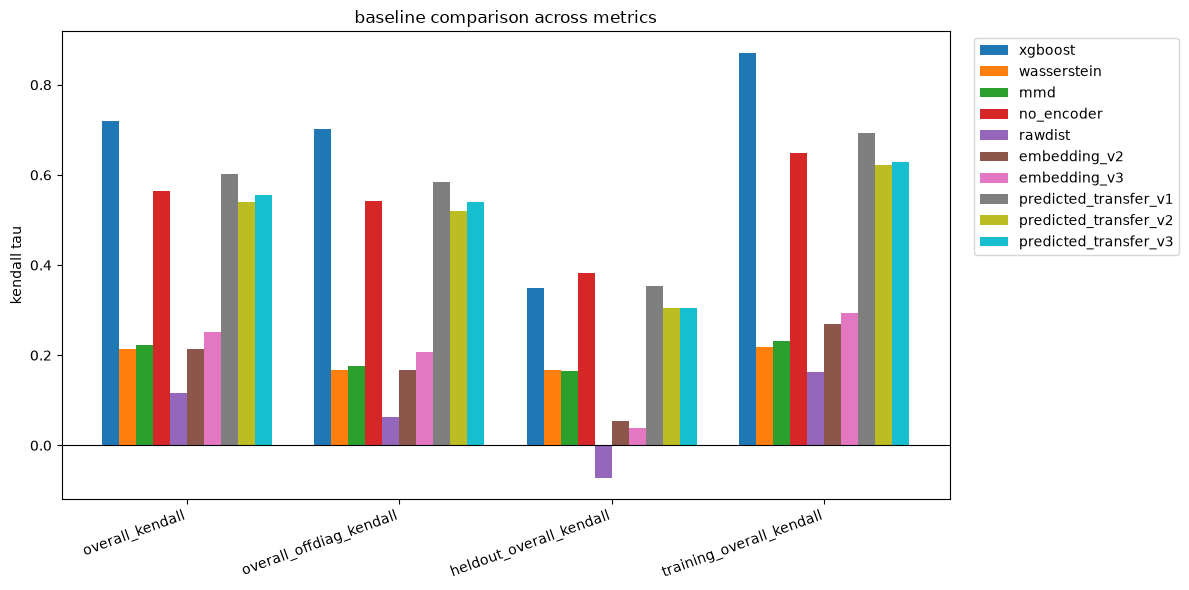

In [152]:
plot_baseline_comparison(results_df)

In [153]:
true_matrix.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.392727,0.291660,0.127238,0.058840,0.214817,0.084705,0.149056,0.182358,0.173877,0.026375,...,0.228505,0.243433,0.149609,0.275203,0.112525,-0.011557,0.116862,0.158796,0.025454,0.029928
1,0.142172,0.395760,0.030643,0.010376,0.180707,0.064432,0.056092,0.128808,0.097788,0.039590,...,0.167477,0.032806,0.029704,0.193033,0.055264,0.066550,0.108203,0.199762,0.023240,-0.037710
2,0.196600,0.214445,0.368173,0.023968,0.207323,0.140139,0.172990,0.231019,0.156741,0.057226,...,0.197402,0.223793,0.121457,0.248807,0.134485,0.053503,-0.005610,0.253965,0.031899,0.059566
4,0.235489,0.227173,0.127394,0.410382,0.215954,0.186207,0.125068,0.196603,0.165264,0.034514,...,0.178055,0.245668,0.147579,0.284360,0.217076,-0.003941,0.037643,0.306750,0.137154,0.020968
5,0.190803,0.206530,0.097887,0.087230,0.464604,0.144950,0.159361,0.204884,0.264641,0.104493,...,0.197195,0.232923,0.117228,0.292623,0.170687,-0.020694,0.115293,0.297271,0.067951,0.051770
